# Skin Cancer Classification — EDA & Preprocessing




## 1. Setup


In [1]:
import os
import glob
from pathlib import Path
DATASET_DIR = "Skin Cancer Detection"   # folder next to this notebook (train/valid/test)
IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp"}
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110
np.random.seed(42)




## 2. Data Loading


In [2]:
records = []
for path in glob.glob(os.path.join(DATASET_DIR, "**", "*"), recursive=True):
    p = Path(path)
    if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
        split = next((s for s in ["train", "valid", "test"] if s in p.parts), "unknown")
        records.append({"filepath": str(p), "label": p.parent.name, "split": split})

df = pd.DataFrame(records)
print("Total images:", len(df))
df.head()


Total images: 16831


,filepath,label,split
0,Skin Cancer Detection\test\akiec\ISIC_0024562_...,akiec,test
1,Skin Cancer Detection\test\akiec\ISIC_0024646_...,akiec,test
2,Skin Cancer Detection\test\akiec\ISIC_0025247_...,akiec,test
3,Skin Cancer Detection\test\akiec\ISIC_0025539_...,akiec,test
4,Skin Cancer Detection\test\akiec\ISIC_0025637_...,akiec,test


## 3. Data Cleaning


In [3]:
import hashlib

def is_valid_image(path):
    try:
        with Image.open(path) as img:
            img.verify()
        return os.path.getsize(path) > 0
    except Exception:
        return False

df["is_valid"] = df["filepath"].apply(is_valid_image)
n_corrupt = (~df["is_valid"]).sum()
print(f"Corrupted/unreadable files: {n_corrupt}")

df = df[df["is_valid"]].drop(columns=["is_valid"]).reset_index(drop=True)

# Duplicate check via MD5 hash of file bytes
def file_hash(path):
    with open(path, "rb") as f:
        return hashlib.md5(f.read()).hexdigest()

df["hash"] = df["filepath"].apply(file_hash)
n_dupes = df["hash"].duplicated().sum()
print(f"Duplicate images: {n_dupes}")

df = df.drop_duplicates(subset="hash").drop(columns=["hash"]).reset_index(drop=True)
print("Clean dataset size:", len(df))


Corrupted/unreadable files: 0
Duplicate images: 1
Clean dataset size: 16830


## 4. Exploratory Data Analysis

### 4.1 Class distribution
Bar chart and an indexed pie chart, both using a clear, distinct color palette so all 7 classes are easy to tell apart.

C:\Users\Asus\AppData\Local\Temp\ipykernel_15988\2116928004.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, palette=palette, ax=axes[0])


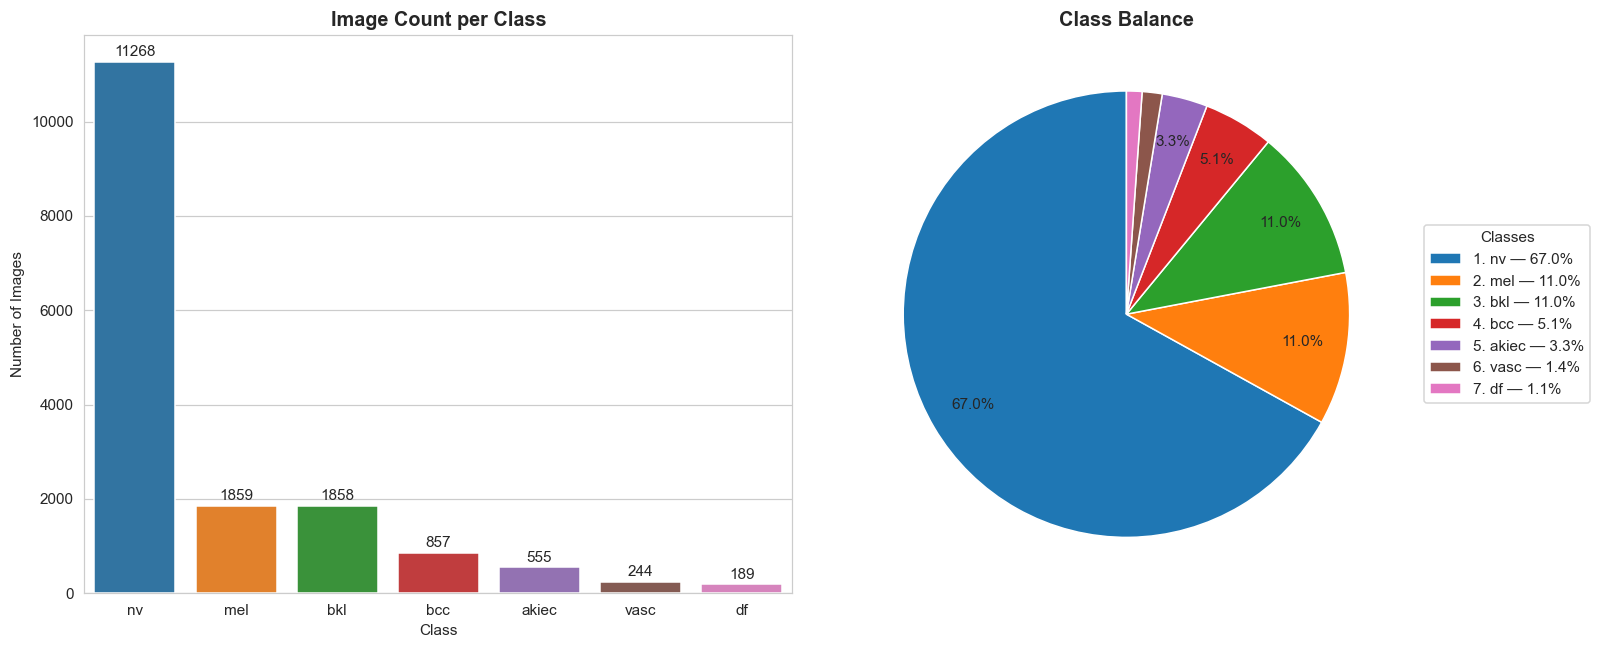

In [4]:
class_counts = df["label"].value_counts()
palette = sns.color_palette("tab10", n_colors=len(class_counts))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
sns.barplot(x=class_counts.index, y=class_counts.values, palette=palette, ax=axes[0])
axes[0].set_title("Image Count per Class", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of Images")
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + max(class_counts.values) * 0.01, str(v), ha="center", fontsize=10)

# Indexed pie chart
labels_idx = [f"{i+1}. {lbl}" for i, lbl in enumerate(class_counts.index)]
percentages = class_counts.values / class_counts.values.sum() * 100
autopct_fn = lambda pct: f"{pct:.1f}%" if pct >= 3 else ""
wedges, _, _ = axes[1].pie(class_counts.values, autopct=autopct_fn, startangle=90,
                            colors=palette, pctdistance=0.8, textprops={"fontsize": 10})
legend_labels = [f"{i+1}. {lbl} — {pct:.1f}%" for i, (lbl, pct) in enumerate(zip(class_counts.index, percentages))]
axes[1].legend(wedges, legend_labels, title="Classes", loc="center left",
               bbox_to_anchor=(1.02, 0.5), fontsize=10)
axes[1].set_title("Class Balance", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.show()


### 4.2 Train / Valid / Test split per class
A stacked bar chart showing how each class is distributed across the three splits — confirms the splits are proportionate and no class is missing from any split.

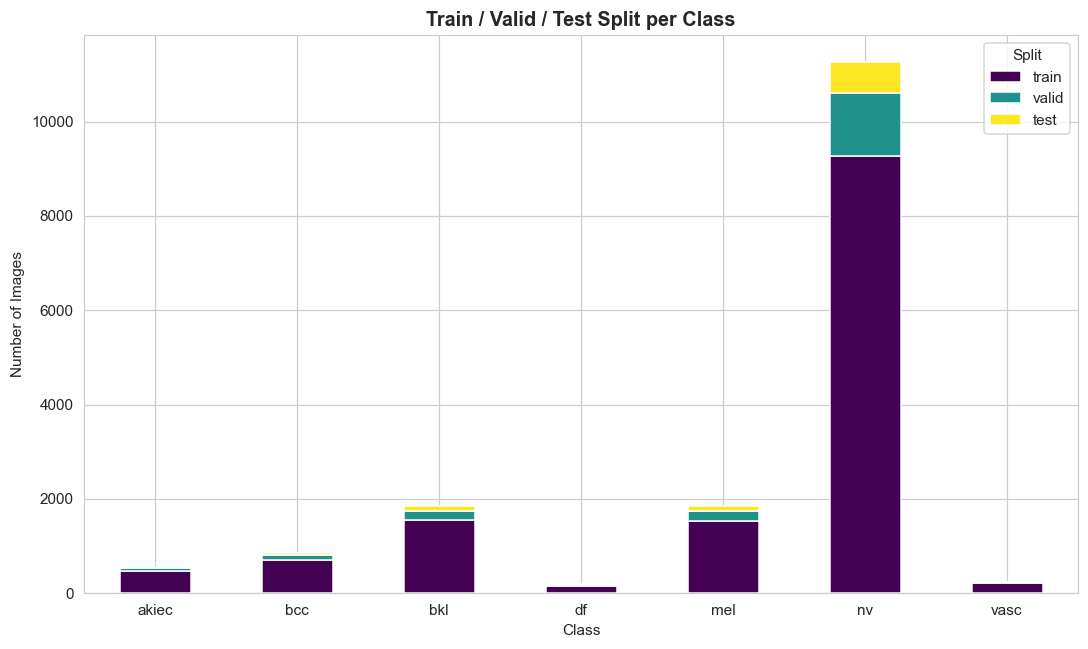

split,train,valid,test
label,,,
akiec,468,59,28
bcc,698,105,54
bkl,1545,202,111
df,148,30,11
mel,1522,226,111
nv,9274,1326,668
vasc,206,30,8


In [5]:
split_counts = df.groupby(["label", "split"]).size().unstack(fill_value=0)
split_counts = split_counts[["train", "valid", "test"]] if set(["train","valid","test"]).issubset(split_counts.columns) else split_counts

split_counts.plot(kind="bar", stacked=True, figsize=(10, 6), colormap="viridis")
plt.title("Train / Valid / Test Split per Class", fontsize=13, fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=0)
plt.legend(title="Split")
plt.tight_layout()
plt.show()

split_counts


### 4.3 Sample images per class
Display a few sample lesion images from each class in a grid, to visually confirm the labels look correct and see how the classes differ in appearance.

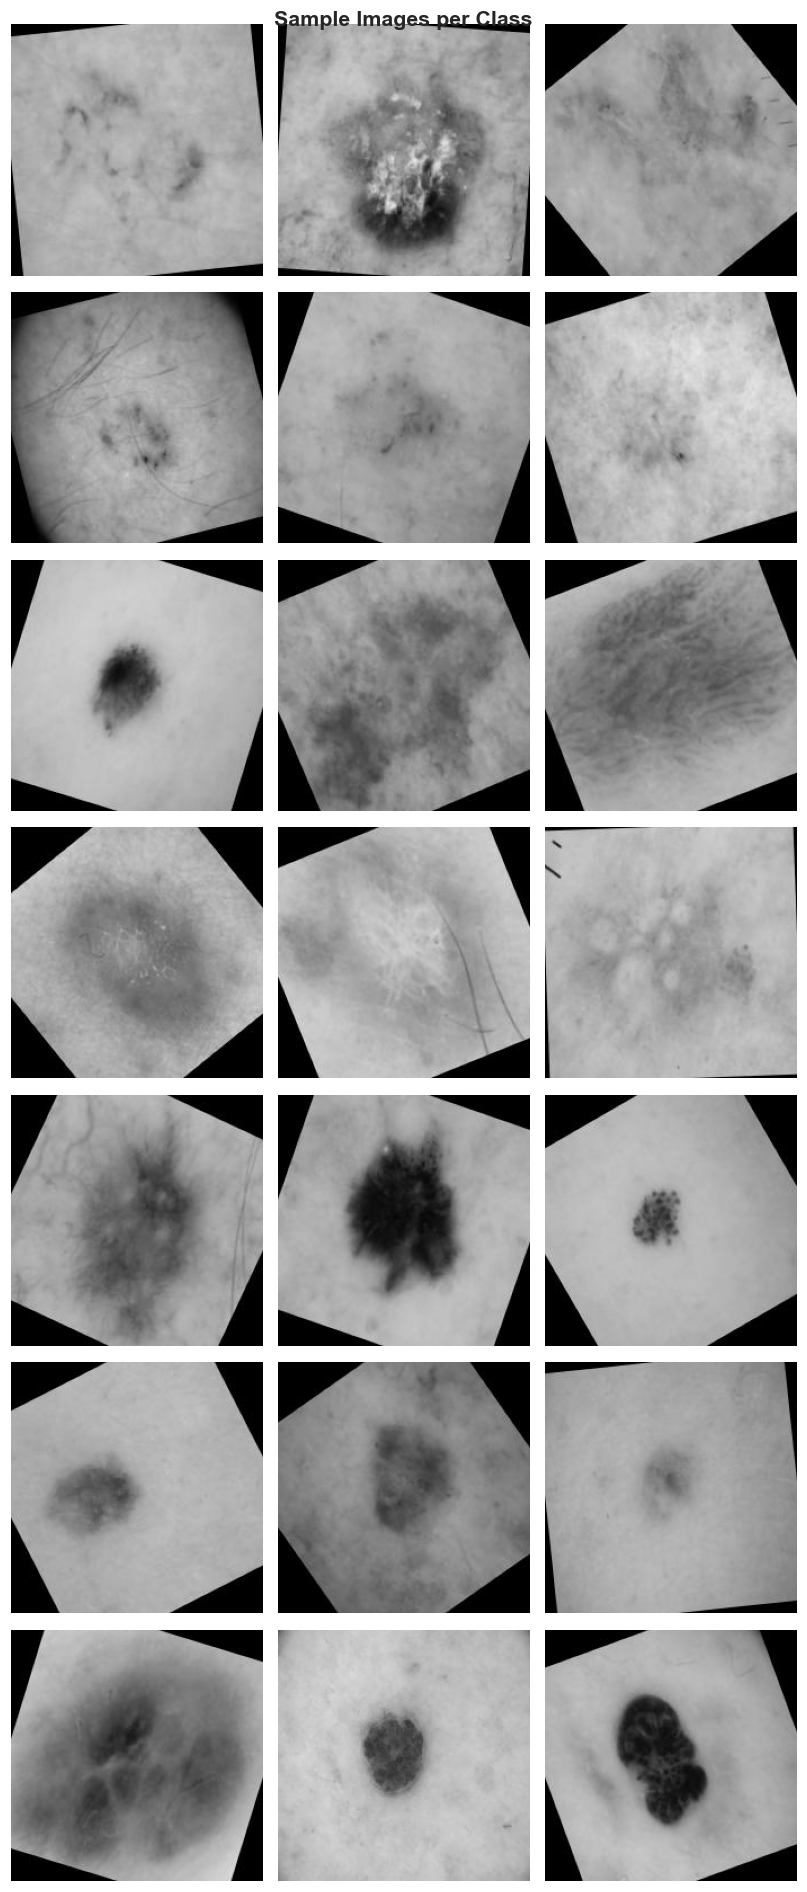

In [6]:
classes = sorted(df["label"].unique())
n_samples = 3

fig, axes = plt.subplots(len(classes), n_samples, figsize=(n_samples * 2.5, len(classes) * 2.5))
for i, cls in enumerate(classes):
    paths = df[df["label"] == cls]["filepath"].sample(n=min(n_samples, (df["label"] == cls).sum()), random_state=1)
    for j, p in enumerate(paths):
        img = Image.open(p).convert("RGB")
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
    axes[i, 0].set_ylabel(cls, fontsize=11, rotation=0, labelpad=40, va="center")

plt.suptitle("Sample Images per Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()



### 4.4 Image dimensions
Sample a subset of images and check their width/height, to see whether resizing is needed before feeding images into a model.

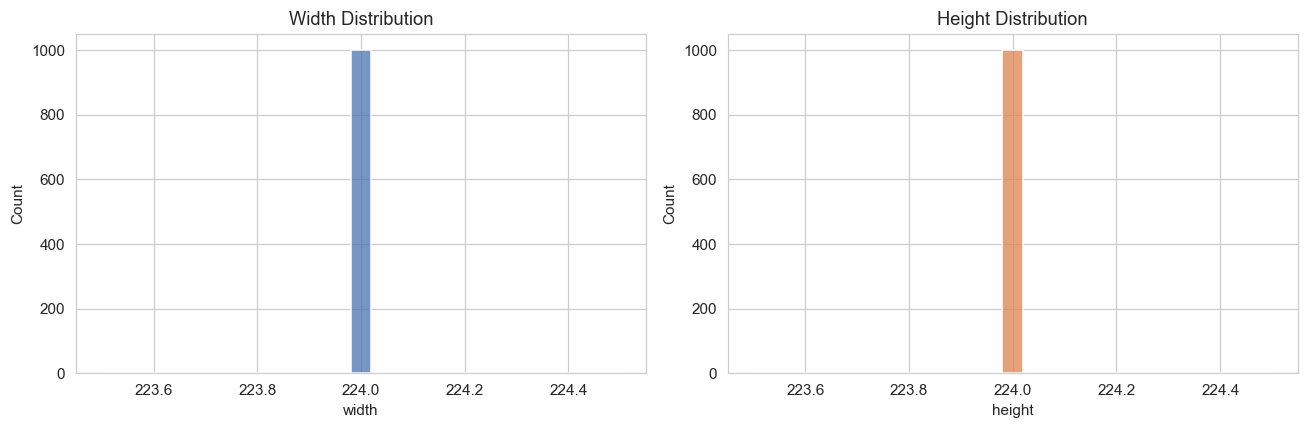

,width,height
count,1000.0,1000.0
mean,224.0,224.0
std,0.0,0.0
min,224.0,224.0
25%,224.0,224.0
50%,224.0,224.0
75%,224.0,224.0
max,224.0,224.0


In [7]:
sample_df = df.sample(n=min(1000, len(df)), random_state=42).copy()
sizes = sample_df["filepath"].apply(lambda p: Image.open(p).size)
sample_df["width"] = sizes.apply(lambda s: s[0])
sample_df["height"] = sizes.apply(lambda s: s[1])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(sample_df["width"], bins=25, color="#4C72B0", ax=axes[0])
axes[0].set_title("Width Distribution")
sns.histplot(sample_df["height"], bins=25, color="#DD8452", ax=axes[1])
axes[1].set_title("Height Distribution")
plt.tight_layout()
plt.show()

sample_df[["width", "height"]].describe()


### 4.5 Average color per class
Compute the mean RGB intensity per class to see if color alone shows any visible difference between lesion types — useful context since color is a diagnostic cue for skin lesions.

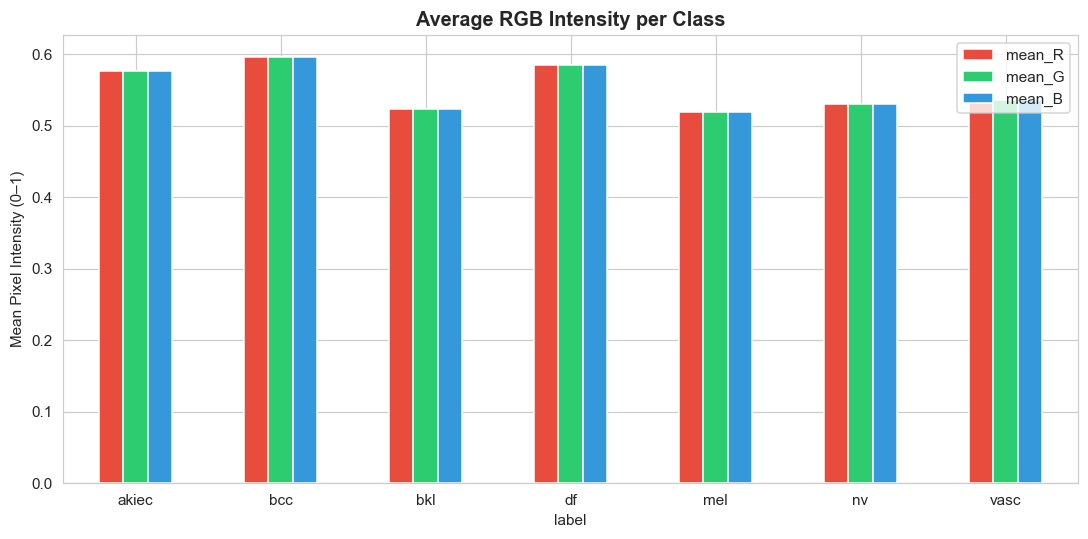

In [8]:
def mean_rgb(path, size=(64, 64)):
    arr = np.array(Image.open(path).convert("RGB").resize(size)) / 255.0
    return arr.reshape(-1, 3).mean(axis=0)

sample_df[["mean_R", "mean_G", "mean_B"]] = pd.DataFrame(
    sample_df["filepath"].apply(mean_rgb).tolist(), index=sample_df.index)

class_rgb = sample_df.groupby("label")[["mean_R", "mean_G", "mean_B"]].mean()

class_rgb.plot(kind="bar", figsize=(10, 5), color=["#E74C3C", "#2ECC71", "#3498DB"])
plt.title("Average RGB Intensity per Class", fontsize=13, fontweight="bold")
plt.ylabel("Mean Pixel Intensity (0–1)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 5. Data Preprocessing


In [9]:
IMG_SIZE = (128, 128)

def load_and_preprocess(path, size=IMG_SIZE):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    img = img / 255.0          # normalize to [0, 1]
    return img

# Quick check on one image
sample_img = load_and_preprocess(df["filepath"].iloc[0])
print("Preprocessed image shape:", sample_img.shape, "| value range:", sample_img.min(), "-", sample_img.max())

# Class weights to handle imbalance (inverse frequency)
class_counts_all = df["label"].value_counts()
total = len(df)
class_weights = {cls: total / (len(class_counts_all) * count) for cls, count in class_counts_all.items()}
pd.Series(class_weights, name="class_weight").sort_values(ascending=False)


Preprocessed image shape: (128, 128, 3) | value range: 0.14901960784313725 - 0.8313725490196079


df       12.721088
vasc      9.853630
akiec     4.332046
bcc       2.805468
bkl       1.294018
mel       1.293322
nv        0.213373
Name: class_weight, dtype: float64

## 6. Neural Network (CNN) Implementation and Model Evaluation 
## Week 4

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, optimizers
from sklearn.metrics import (confusion_matrix, classification_report,
                              precision_recall_fscore_support, accuracy_score)

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

tf.random.set_seed(42)

TensorFlow: 2.20.0
GPU available: []


# 6.1 Data generators 

In [11]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE   = (128, 128)     # keep consistent with Section 5 preprocessing
BATCH_SIZE = 32
NUM_CLASSES = df["label"].nunique()
CLASS_NAMES = sorted(df["label"].unique())
print(f"Classes ({NUM_CLASSES}): {CLASS_NAMES}")

train_df = df[df["split"] == "train"].reset_index(drop=True)
valid_df = df[df["split"] == "valid"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)
print("Train:", len(train_df), "| Valid:", len(valid_df), "| Test:", len(test_df))

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,        # lesions have no canonical orientation
)
eval_datagen = ImageDataGenerator(rescale=1./255)

def make_generator(datagen, dataframe, shuffle):
    return datagen.flow_from_dataframe(
        dataframe=dataframe,
        x_col="filepath",
        y_col="label",
        target_size=IMG_SIZE,
        class_mode="categorical",
        classes=CLASS_NAMES,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=42,
    )

train_gen = make_generator(train_datagen, train_df, shuffle=True)
valid_gen = make_generator(eval_datagen, valid_df, shuffle=False)
test_gen  = make_generator(eval_datagen, test_df,  shuffle=False)


Classes (7): ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Train: 13861 | Valid: 1978 | Test: 991
Found 13861 validated image filenames belonging to 7 classes.
Found 1978 validated image filenames belonging to 7 classes.
Found 991 validated image filenames belonging to 7 classes.


## 6.2 CNN Architeture 

In [12]:
def build_cnn(input_shape=(128, 128, 3), num_classes=NUM_CLASSES,
              conv_filters=(32, 64, 128), dense_units=128,
              dropout_rate=0.4, learning_rate=1e-3, optimizer_name="adam"):
    """Builds and compiles a configurable CNN classifier."""
    inputs = keras.Input(shape=input_shape)
    x = inputs
    for filters in conv_filters:
        x = layers.Conv2D(filters, (3, 3), padding="same")(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.MaxPooling2D(pool_size=(2, 2))(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(dense_units, activation="relu")(x)
    x = layers.Dropout(dropout_rate)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)

    if optimizer_name == "adam":
        opt = optimizers.Adam(learning_rate=learning_rate)
    elif optimizer_name == "rmsprop":
        opt = optimizers.RMSprop(learning_rate=learning_rate)
    else:
        opt = optimizers.SGD(learning_rate=learning_rate, momentum=0.9)

    model.compile(optimizer=opt, loss="categorical_crossentropy",
                  metrics=["accuracy"])
    return model

baseline_model = build_cnn()
baseline_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,559 (435.78 KB)

 Trainable params: 111,111 (434.03 KB)

 Non-trainable params: 448 (1.75 KB)

## 6.3 Baseline Training 

In [13]:
EPOCHS = 3 

cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
]

history_baseline = baseline_model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=cb,
)

Epoch 1/3
434/434 ━━━━━━━━━━━━━━━━━━━━ 511s 1s/step - accuracy: 0.6682 - loss: 1.0589 - val_accuracy: 0.6704 - val_loss: 1.5136 - learning_rate: 0.0010
Epoch 2/3
434/434 ━━━━━━━━━━━━━━━━━━━━ 598s 1s/step - accuracy: 0.6777 - loss: 0.9771 - val_accuracy: 0.6754 - val_loss: 1.2630 - learning_rate: 0.0010
Epoch 3/3
434/434 ━━━━━━━━━━━━━━━━━━━━ 757s 2s/step - accuracy: 0.6833 - loss: 0.9431 - val_accuracy: 0.6719 - val_loss: 1.5023 - learning_rate: 0.0010


## 6.4 Baseline Training Curves 

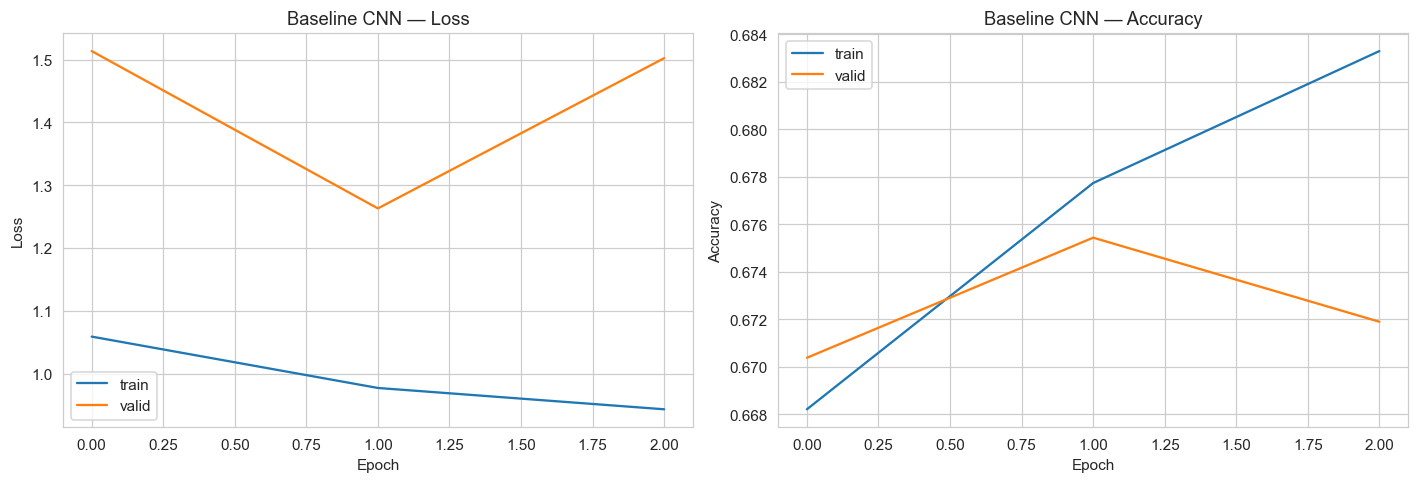

In [14]:
def plot_history(history, title="Training History"):
    hist = history.history
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(hist["loss"], label="train")
    axes[0].plot(hist["val_loss"], label="valid")
    axes[0].set_title(f"{title} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()

    axes[1].plot(hist["accuracy"], label="train")
    axes[1].plot(hist["val_accuracy"], label="valid")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()

    plt.tight_layout()
    plt.show()

plot_history(history_baseline, "Baseline CNN")

## 7.1 Hyperparameter Training 

In [15]:
experiment_configs = [
    {"name": "baseline (lr=1e-3, adam, drop=0.4, bs=32)",
     "learning_rate": 1e-3, "optimizer_name": "adam", "dropout_rate": 0.4, "batch_size": 32},
    {"name": "lower lr (lr=1e-4, adam, drop=0.4, bs=32)",
     "learning_rate": 1e-4, "optimizer_name": "adam", "dropout_rate": 0.4, "batch_size": 32},
    {"name": "rmsprop (lr=1e-3, rmsprop, drop=0.4, bs=32)",
     "learning_rate": 1e-3, "optimizer_name": "rmsprop", "dropout_rate": 0.4, "batch_size": 32},
    {"name": "more dropout (lr=1e-3, adam, drop=0.5, bs=32)",
     "learning_rate": 1e-3, "optimizer_name": "adam", "dropout_rate": 0.5, "batch_size": 32},
    {"name": "larger batch (lr=1e-3, adam, drop=0.4, bs=64)",
     "learning_rate": 1e-3, "optimizer_name": "adam", "dropout_rate": 0.4, "batch_size": 64},
]

TUNE_EPOCHS = 3
tune_cb = [callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)]

results = []
histories = {}

for cfg in experiment_configs:
    print("=" * 70)
    print("Training:", cfg["name"])
    print("=" * 70)

    bs = cfg["batch_size"]
    tg = make_generator(train_datagen, train_df, shuffle=True)
    tg.batch_size = bs
    vg = make_generator(eval_datagen, valid_df, shuffle=False)
    vg.batch_size = bs

    model = build_cnn(learning_rate=cfg["learning_rate"],
                       optimizer_name=cfg["optimizer_name"],
                       dropout_rate=cfg["dropout_rate"])

    hist = model.fit(tg, validation_data=vg, epochs=TUNE_EPOCHS,
                      class_weight=class_weights, callbacks=tune_cb, verbose=1)

    best_val_acc = max(hist.history["val_accuracy"])
    best_val_loss = min(hist.history["val_loss"])
    results.append({"config": cfg["name"], "best_val_accuracy": best_val_acc,
                     "best_val_loss": best_val_loss})
    histories[cfg["name"]] = hist

results_df = pd.DataFrame(results).sort_values("best_val_accuracy", ascending=False)
results_df

Training: baseline (lr=1e-3, adam, drop=0.4, bs=32)
Found 13861 validated image filenames belonging to 7 classes.
Found 1978 validated image filenames belonging to 7 classes.
Epoch 1/3
434/434 ━━━━━━━━━━━━━━━━━━━━ 573s 1s/step - accuracy: 0.6643 - loss: 1.0731 - val_accuracy: 0.6704 - val_loss: 1.9270
Epoch 2/3
434/434 ━━━━━━━━━━━━━━━━━━━━ 776s 2s/step - accuracy: 0.6746 - loss: 0.9856 - val_accuracy: 0.6744 - val_loss: 1.0904
Epoch 3/3
434/434 ━━━━━━━━━━━━━━━━━━━━ 765s 2s/step - accuracy: 0.6825 - loss: 0.9478 - val_accuracy: 0.4444 - val_loss: 1.3622
Training: lower lr (lr=1e-4, adam, drop=0.4, bs=32)
Found 13861 validated image filenames belonging to 7 classes.
Found 1978 validated image filenames belonging to 7 classes.
Epoch 1/3
434/434 ━━━━━━━━━━━━━━━━━━━━ 713s 2s/step - accuracy: 0.6472 - loss: 1.1493 - val_accuracy: 0.6684 - val_loss: 1.0835
Epoch 2/3
434/434 ━━━━━━━━━━━━━━━━━━━━ 803s 2s/step - accuracy: 0.6750 - loss: 1.0078 - val_accuracy: 0.6259 - val_loss: 1.1619
Epoch 3/3


,config,best_val_accuracy,best_val_loss
0,"baseline (lr=1e-3, adam, drop=0.4, bs=32)",0.674419,1.090432
4,"larger batch (lr=1e-3, adam, drop=0.4, bs=64)",0.672902,1.187615
2,"rmsprop (lr=1e-3, rmsprop, drop=0.4, bs=32)",0.670374,1.151740
3,"more dropout (lr=1e-3, adam, drop=0.5, bs=32)",0.670374,1.080208
1,"lower lr (lr=1e-4, adam, drop=0.4, bs=32)",0.668352,1.083542


## 7.2 Comparing Configurateion 

C:\Users\Asus\AppData\Local\Temp\ipykernel_15988\3484318873.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="best_val_accuracy", y="config",
C:\Users\Asus\AppData\Local\Temp\ipykernel_15988\3484318873.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="best_val_loss", y="config",


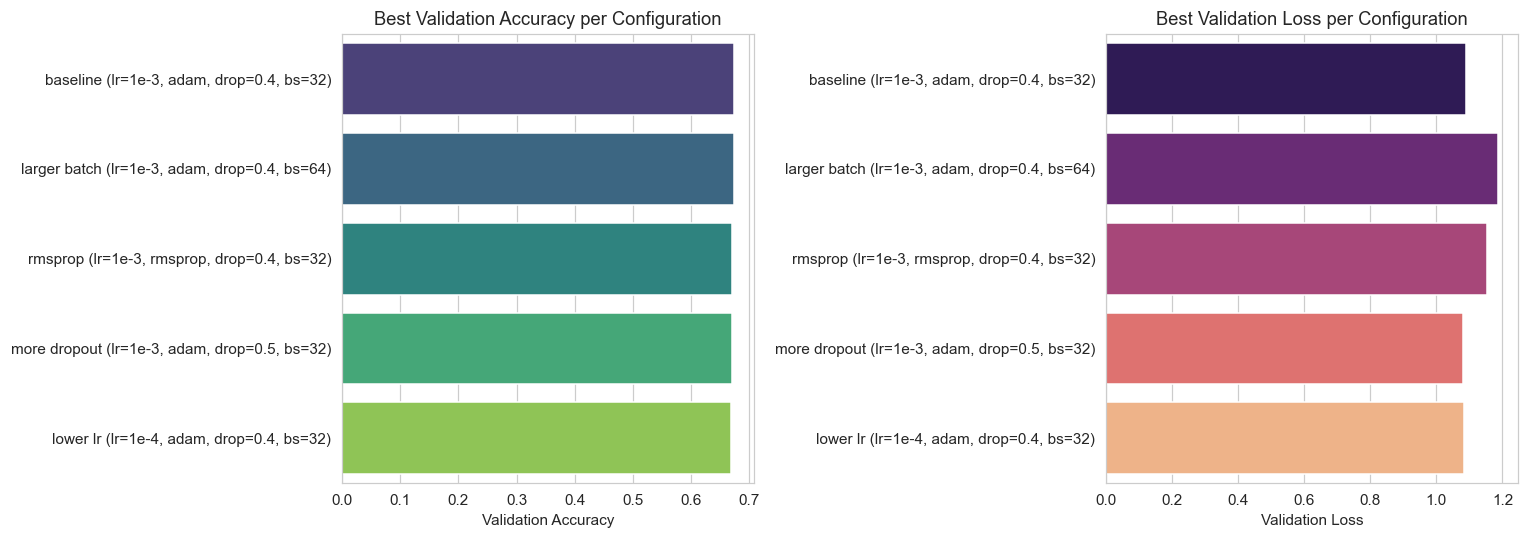

Best configuration: {'name': 'baseline (lr=1e-3, adam, drop=0.4, bs=32)', 'learning_rate': 0.001, 'optimizer_name': 'adam', 'dropout_rate': 0.4, 'batch_size': 32}


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(data=results_df, x="best_val_accuracy", y="config",
            palette="viridis", ax=axes[0])
axes[0].set_title("Best Validation Accuracy per Configuration")
axes[0].set_xlabel("Validation Accuracy"); axes[0].set_ylabel("")

sns.barplot(data=results_df, x="best_val_loss", y="config",
            palette="magma", ax=axes[1])
axes[1].set_title("Best Validation Loss per Configuration")
axes[1].set_xlabel("Validation Loss"); axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

best_cfg_name = results_df.iloc[0]["config"]
best_cfg = next(c for c in experiment_configs if c["name"] == best_cfg_name)
print("Best configuration:", best_cfg)

## 8 Final Model Training 

Found 13861 validated image filenames belonging to 7 classes.
Found 1978 validated image filenames belonging to 7 classes.
Found 991 validated image filenames belonging to 7 classes.
Epoch 1/3
434/434 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6648 - loss: 1.0683

434/434 ━━━━━━━━━━━━━━━━━━━━ 602s 1s/step - accuracy: 0.6648 - loss: 1.0683 - val_accuracy: 0.6704 - val_loss: 1.3238 - learning_rate: 0.0010
Epoch 2/3
434/434 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6766 - loss: 0.9899

434/434 ━━━━━━━━━━━━━━━━━━━━ 544s 1s/step - accuracy: 0.6766 - loss: 0.9899 - val_accuracy: 0.6734 - val_loss: 1.0183 - learning_rate: 0.0010
Epoch 3/3
434/434 ━━━━━━━━━━━━━━━━━━━━ 553s 1s/step - accuracy: 0.6839 - loss: 0.9409 - val_accuracy: 0.3327 - val_loss: 3.0895 - learning_rate: 0.0010


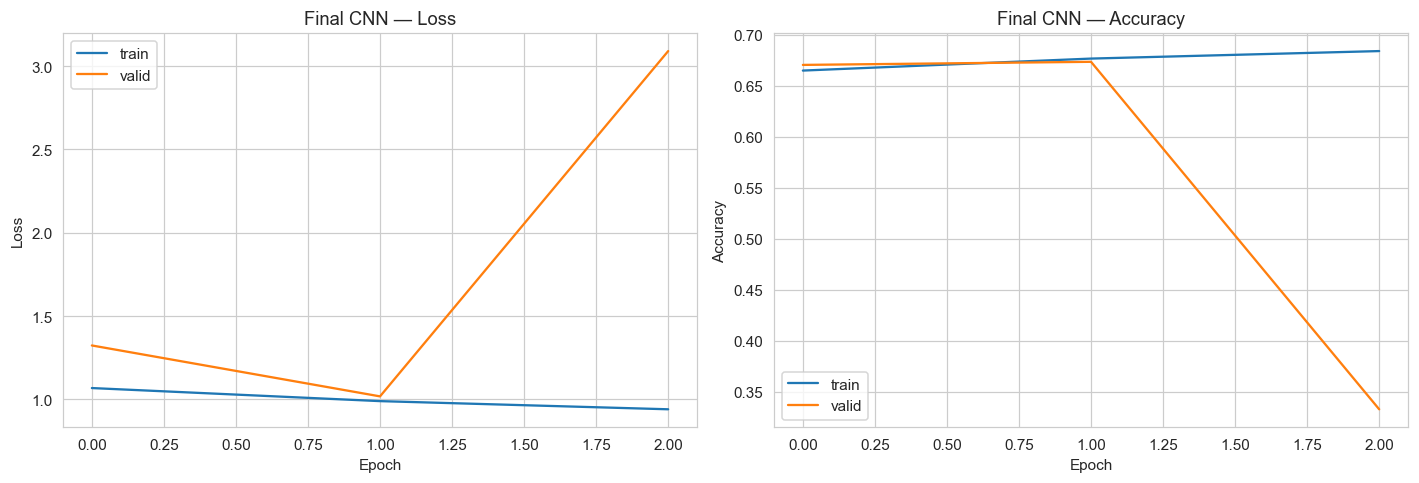

In [18]:
final_train_gen = make_generator(train_datagen, train_df, shuffle=True)
final_train_gen.batch_size = best_cfg["batch_size"]
final_valid_gen = make_generator(eval_datagen, valid_df, shuffle=False)
final_valid_gen.batch_size = best_cfg["batch_size"]
final_test_gen  = make_generator(eval_datagen, test_df, shuffle=False)
final_test_gen.batch_size = best_cfg["batch_size"]

final_model = build_cnn(learning_rate=best_cfg["learning_rate"],
                         optimizer_name=best_cfg["optimizer_name"],
                         dropout_rate=best_cfg["dropout_rate"])

final_cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6),
    callbacks.ModelCheckpoint("best_skin_cancer_cnn.h5", monitor="val_accuracy",
                               save_best_only=True),
]

history_final = final_model.fit(
    final_train_gen,
    validation_data=final_valid_gen,
    epochs=3,
    class_weight=class_weights,
    callbacks=final_cb,
)

plot_history(history_final, "Final CNN")

## 9.1 Evaluation on Test Set 

In [19]:
final_test_gen.reset()
y_true = final_test_gen.classes
pred_probs = final_model.predict(final_test_gen, verbose=1)
y_pred = np.argmax(pred_probs, axis=1)

test_accuracy = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

31/31 ━━━━━━━━━━━━━━━━━━━━ 8s 234ms/step
Test Accuracy: 0.6771


## 9.2 Confusion Matrix 

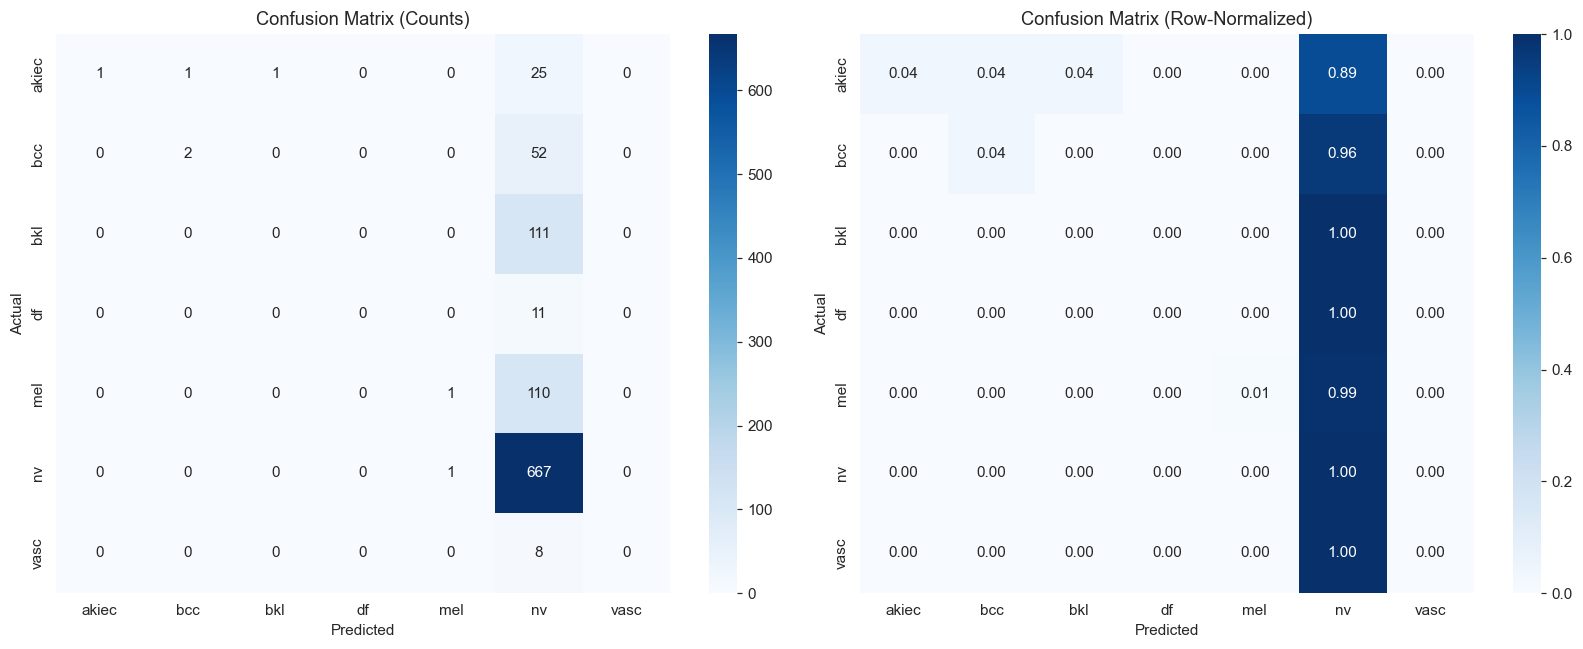

In [20]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Confusion Matrix (Row-Normalized)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

## 9.3 F1 score, Recall, Precision 

In [21]:
report_dict = classification_report(y_true, y_pred, target_names=CLASS_NAMES,
                                     output_dict=True, zero_division=0)
report_df = pd.DataFrame(report_dict).transpose()
report_df

,precision,recall,f1-score,support
akiec,1.000000,0.035714,0.068966,28.000000
bcc,0.666667,0.037037,0.070175,54.000000
bkl,0.000000,0.000000,0.000000,111.000000
df,0.000000,0.000000,0.000000,11.000000
mel,0.500000,0.009009,0.017699,111.000000
nv,0.677846,0.998503,0.807506,668.000000
vasc,0.000000,0.000000,0.000000,8.000000
accuracy,0.677094,0.677094,0.677094,0.677094
macro avg,0.406359,0.154323,0.137764,991.000000
weighted avg,0.577498,0.677094,0.552068,991.000000


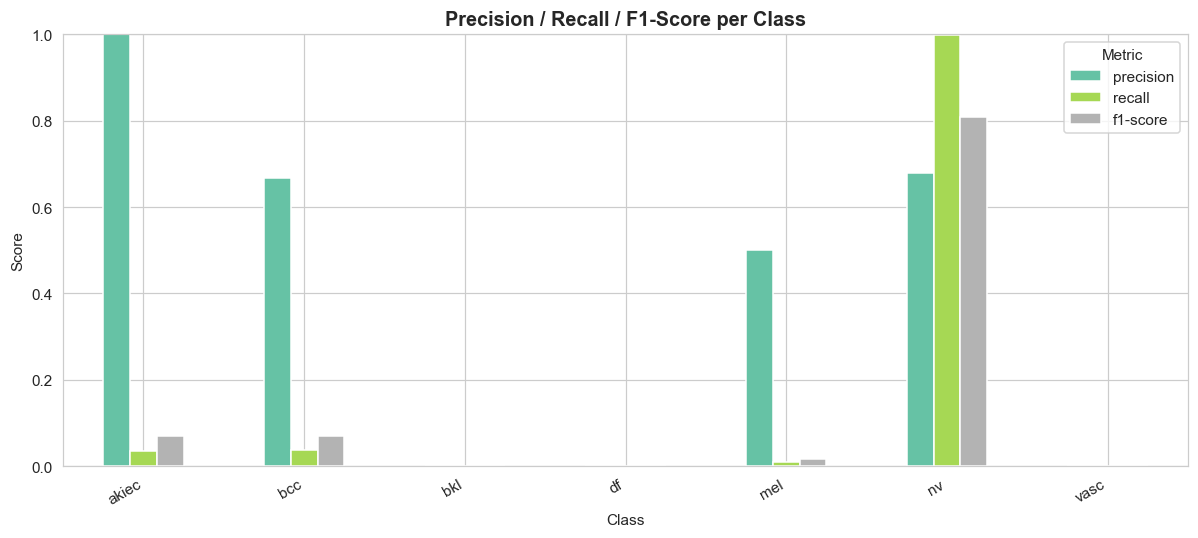

              precision    recall  f1-score   support

       akiec       1.00      0.04      0.07        28
         bcc       0.67      0.04      0.07        54
         bkl       0.00      0.00      0.00       111
          df       0.00      0.00      0.00        11
         mel       0.50      0.01      0.02       111
          nv       0.68      1.00      0.81       668
        vasc       0.00      0.00      0.00         8

    accuracy                           0.68       991
   macro avg       0.41      0.15      0.14       991
weighted avg       0.58      0.68      0.55       991



In [22]:
per_class = report_df.loc[CLASS_NAMES, ["precision", "recall", "f1-score"]]

per_class.plot(kind="bar", figsize=(11, 5), colormap="Set2")
plt.title("Precision / Recall / F1-Score per Class", fontsize=13, fontweight="bold")
plt.ylabel("Score"); plt.xlabel("Class")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))

## 9.4 Missclassified Examples 

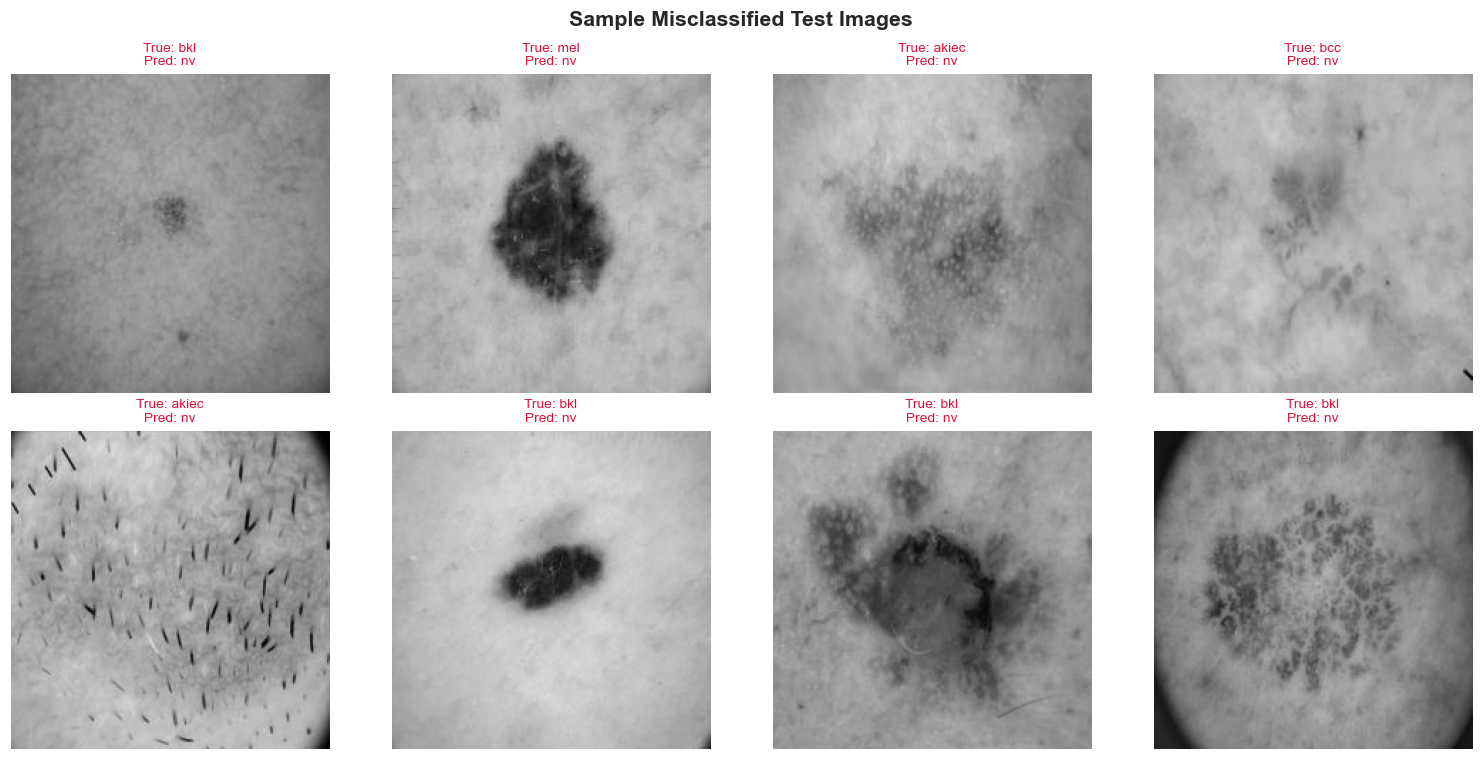

In [23]:
mis_idx = np.where(y_true != y_pred)[0]
n_show = min(8, len(mis_idx))
show_idx = np.random.RandomState(42).choice(mis_idx, size=n_show, replace=False) if n_show else []

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()
for ax, idx in zip(axes, show_idx):
    filepath = test_df.iloc[idx]["filepath"]
    img = Image.open(filepath).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"True: {CLASS_NAMES[y_true[idx]]}\nPred: {CLASS_NAMES[y_pred[idx]]}",
                 fontsize=9, color="crimson")
    ax.axis("off")
for ax in axes[len(show_idx):]:
    ax.axis("off")

plt.suptitle("Sample Misclassified Test Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()


## 9.5 AUC-ROC Curve (CNN)



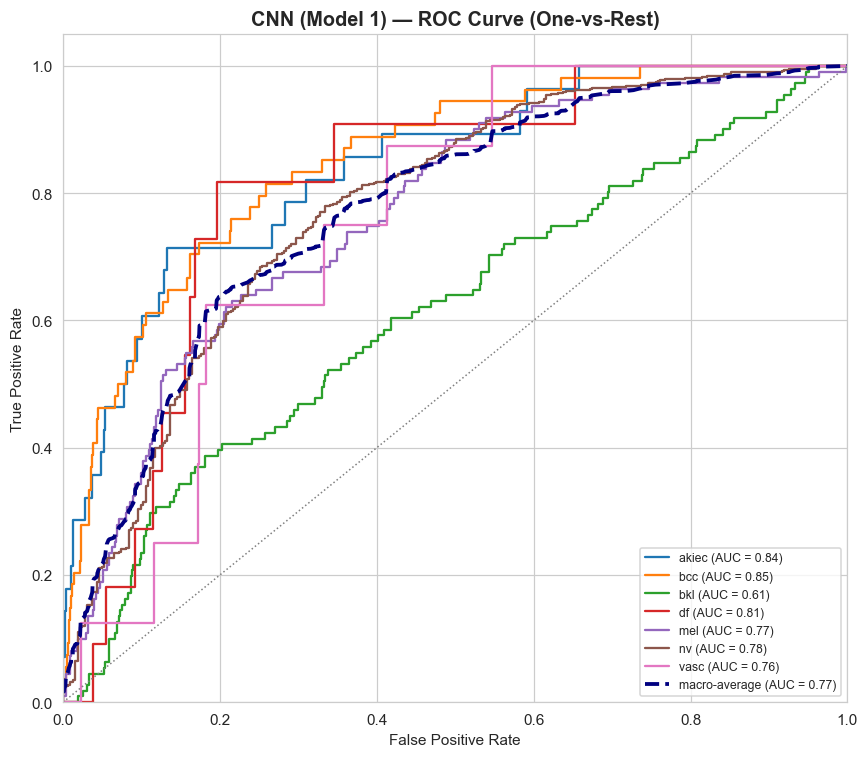

Per-class AUC: {'akiec': 0.841, 'bcc': 0.852, 'bkl': 0.613, 'df': 0.809, 'mel': 0.767, 'nv': 0.777, 'vasc': 0.755}
Macro-average AUC: 0.774


In [24]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

def plot_multiclass_roc(y_true, y_probs, class_names, title="ROC Curve"):
    """Plots one-vs-rest ROC curves (+ macro-average) for a multi-class classifier.
    Returns a dict of per-class AUC plus the macro-average AUC.
    """
    n_classes = len(class_names)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # macro-average
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    roc_auc["macro"] = auc(all_fpr, mean_tpr)

    plt.figure(figsize=(8, 7))
    for i in range(n_classes):
        plt.plot(fpr[i], tpr[i], lw=1.5,
                 label=f"{class_names[i]} (AUC = {roc_auc[i]:.2f})")
    plt.plot(all_fpr, mean_tpr, color="navy", lw=2.5, linestyle="--",
              label=f"macro-average (AUC = {roc_auc['macro']:.2f})")
    plt.plot([0, 1], [0, 1], color="grey", lw=1, linestyle=":")
    plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(title, fontsize=13, fontweight="bold")
    plt.legend(loc="lower right", fontsize=8)
    plt.tight_layout()
    plt.show()

    return roc_auc

roc_auc_cnn = plot_multiclass_roc(y_true, pred_probs, CLASS_NAMES, title="CNN (Model 1) — ROC Curve (One-vs-Rest)")
print("Per-class AUC:", {CLASS_NAMES[i]: round(roc_auc_cnn[i], 3) for i in range(len(CLASS_NAMES))})
print("Macro-average AUC:", round(roc_auc_cnn["macro"], 3))


## 10. Model 2 — Transfer Learning CNN (MobileNetV2)



### 10.1 Data Generators (MobileNetV2 preprocessing)



In [25]:
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input

tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
)
tl_eval_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

tl_train_gen = make_generator(tl_train_datagen, train_df, shuffle=True)
tl_valid_gen = make_generator(tl_eval_datagen, valid_df, shuffle=False)
tl_test_gen  = make_generator(tl_eval_datagen, test_df,  shuffle=False)


Found 13861 validated image filenames belonging to 7 classes.
Found 1978 validated image filenames belonging to 7 classes.
Found 991 validated image filenames belonging to 7 classes.


### 10.2 Model Architecture


In [26]:
def build_transfer_model(input_shape=(128, 128, 3), num_classes=NUM_CLASSES, learning_rate=1e-3):
    base = MobileNetV2(input_shape=input_shape, include_top=False, weights="imagenet")
    base.trainable = False   # freeze pretrained feature extractor

    inputs = keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = models.Model(inputs, outputs)
    model.compile(optimizer=optimizers.Adam(learning_rate=learning_rate),
                  loss="categorical_crossentropy", metrics=["accuracy"])
    return model

transfer_model = build_transfer_model()
transfer_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

### 10.3 Training


In [27]:
tl_cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

history_transfer = transfer_model.fit(
    tl_train_gen,
    validation_data=tl_valid_gen,
    steps_per_epoch=60,      # increase (or remove) for a full training run
    validation_steps=20,
    epochs=6,
    class_weight=class_weights,
    callbacks=tl_cb,
)


Epoch 1/6
60/60 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.6240 - loss: 1.2679 - val_accuracy: 0.0750 - val_loss: 2.2651 - learning_rate: 0.0010
Epoch 2/6
60/60 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6943 - loss: 0.9304 - val_accuracy: 0.0516 - val_loss: 2.3588 - learning_rate: 0.0010
Epoch 3/6
60/60 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.6677 - loss: 0.9844 - val_accuracy: 0.0781 - val_loss: 2.2732 - learning_rate: 0.0010
Epoch 4/6
60/60 ━━━━━━━━━━━━━━━━━━━━ 64s 1s/step - accuracy: 0.6938 - loss: 0.9083 - val_accuracy: 0.1000 - val_loss: 2.1198 - learning_rate: 5.0000e-04
Epoch 5/6
60/60 ━━━━━━━━━━━━━━━━━━━━ 44s 733ms/step - accuracy: 0.6880 - loss: 0.9117 - val_accuracy: 0.1000 - val_loss: 2.2267 - learning_rate: 5.0000e-04
Epoch 6/6
60/60 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.6880 - loss: 0.8924 - val_accuracy: 0.1172 - val_loss: 2.1120 - learning_rate: 5.0000e-04


### 10.4 Training Curves

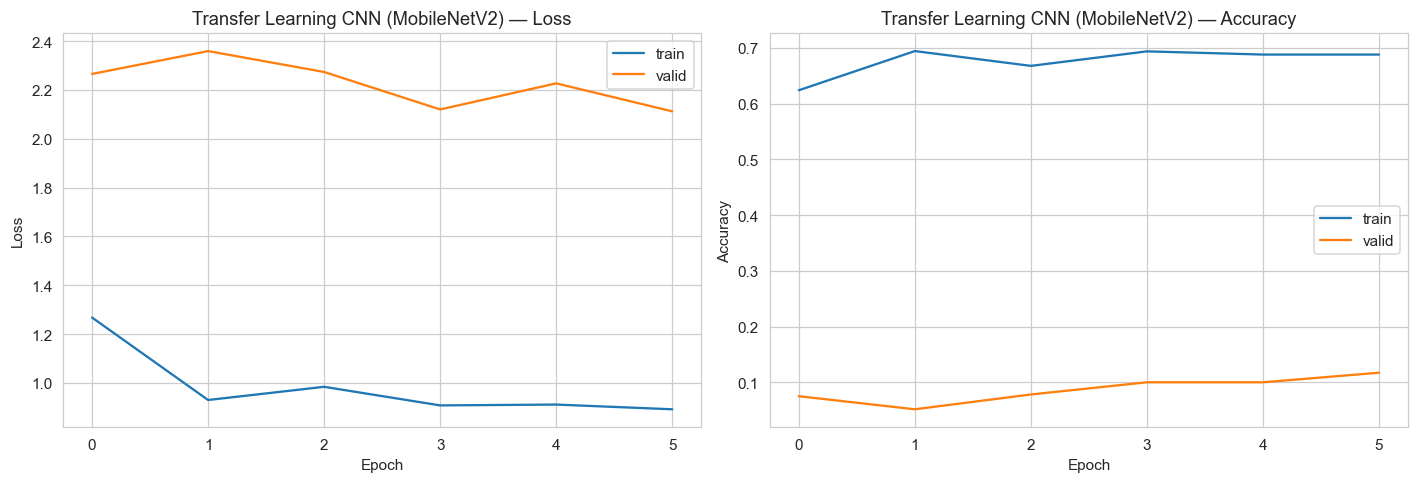

In [28]:
plot_history(history_transfer, "Transfer Learning CNN (MobileNetV2)")


### 10.5 Evaluation on Test Set

In [29]:
tl_test_gen.reset()
y_true_tl = tl_test_gen.classes
pred_probs_tl = transfer_model.predict(tl_test_gen, verbose=1)
y_pred_tl = np.argmax(pred_probs_tl, axis=1)

test_accuracy_tl = accuracy_score(y_true_tl, y_pred_tl)
print(f"Transfer Learning CNN — Test Accuracy: {test_accuracy_tl:.4f}")


31/31 ━━━━━━━━━━━━━━━━━━━━ 14s 364ms/step
Transfer Learning CNN — Test Accuracy: 0.6973


### 10.6 Confusion Matrix

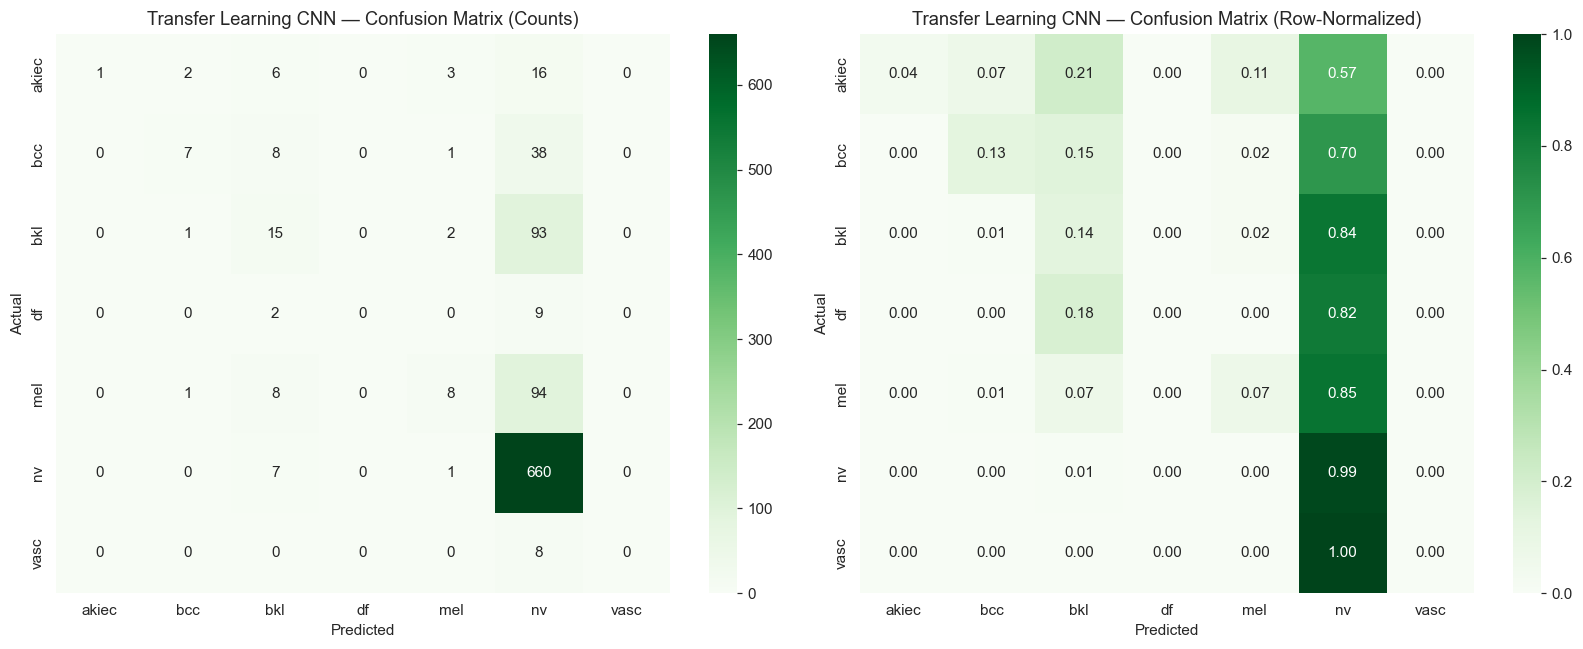

In [30]:
cm_tl = confusion_matrix(y_true_tl, y_pred_tl)
cm_tl_norm = cm_tl.astype(float) / cm_tl.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(cm_tl, annot=True, fmt="d", cmap="Greens",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Transfer Learning CNN — Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(cm_tl_norm, annot=True, fmt=".2f", cmap="Greens",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Transfer Learning CNN — Confusion Matrix (Row-Normalized)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


### 10.7 Precision, Recall, F1-Score

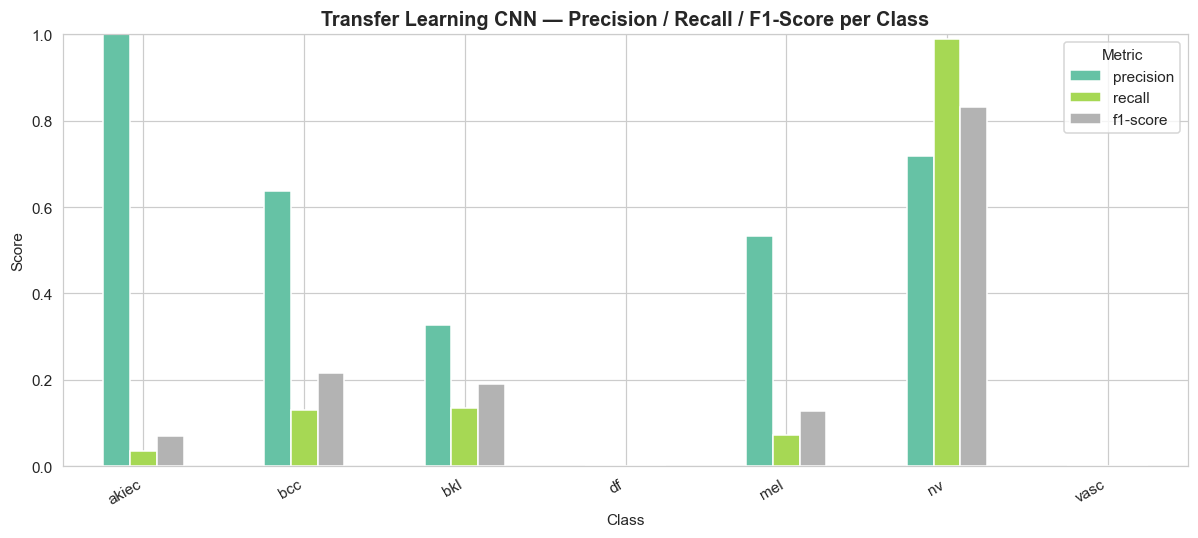

              precision    recall  f1-score   support

       akiec       1.00      0.04      0.07        28
         bcc       0.64      0.13      0.22        54
         bkl       0.33      0.14      0.19       111
          df       0.00      0.00      0.00        11
         mel       0.53      0.07      0.13       111
          nv       0.72      0.99      0.83       668
        vasc       0.00      0.00      0.00         8

    accuracy                           0.70       991
   macro avg       0.46      0.19      0.20       991
weighted avg       0.64      0.70      0.61       991



,precision,recall,f1-score,support
akiec,1.000000,0.035714,0.068966,28.000000
bcc,0.636364,0.129630,0.215385,54.000000
bkl,0.326087,0.135135,0.191083,111.000000
df,0.000000,0.000000,0.000000,11.000000
mel,0.533333,0.072072,0.126984,111.000000
nv,0.718954,0.988024,0.832282,668.000000
vasc,0.000000,0.000000,0.000000,8.000000
accuracy,0.697275,0.697275,0.697275,0.697275
macro avg,0.459248,0.194368,0.204957,991.000000
weighted avg,0.643815,0.697275,0.610325,991.000000


In [31]:
report_dict_tl = classification_report(y_true_tl, y_pred_tl, target_names=CLASS_NAMES,
                                        output_dict=True, zero_division=0)
report_df_tl = pd.DataFrame(report_dict_tl).transpose()

per_class_tl = report_df_tl.loc[CLASS_NAMES, ["precision", "recall", "f1-score"]]
per_class_tl.plot(kind="bar", figsize=(11, 5), colormap="Set2")
plt.title("Transfer Learning CNN — Precision / Recall / F1-Score per Class", fontsize=13, fontweight="bold")
plt.ylabel("Score"); plt.xlabel("Class")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

print(classification_report(y_true_tl, y_pred_tl, target_names=CLASS_NAMES, zero_division=0))
report_df_tl


### 10.8 AUC-ROC Curve

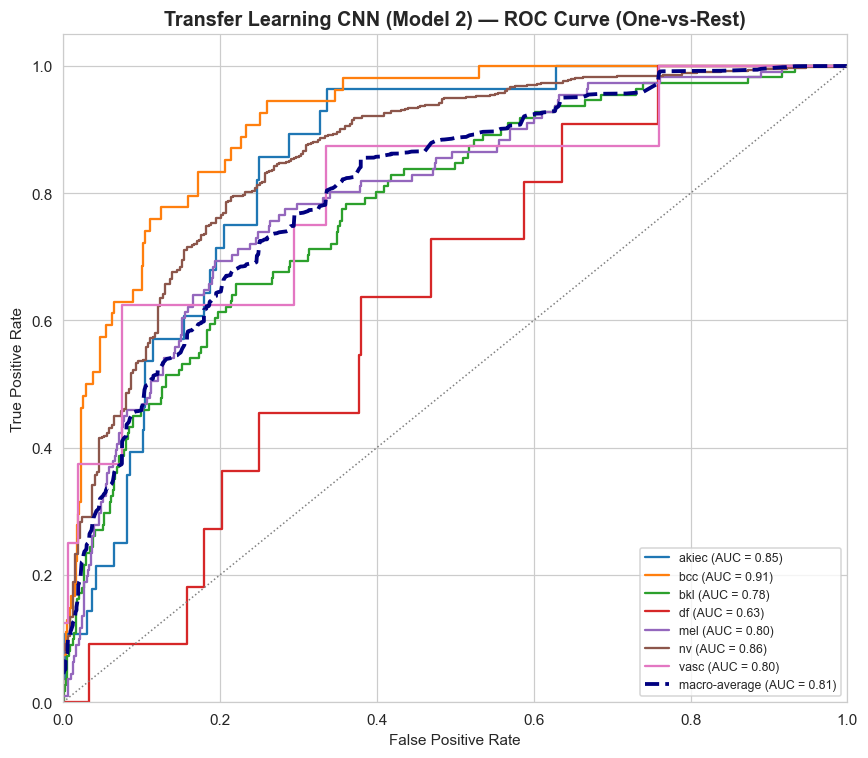

Per-class AUC: {'akiec': 0.847, 'bcc': 0.912, 'bkl': 0.78, 'df': 0.633, 'mel': 0.802, 'nv': 0.86, 'vasc': 0.804}
Macro-average AUC: 0.806


In [32]:
roc_auc_tl = plot_multiclass_roc(y_true_tl, pred_probs_tl, CLASS_NAMES,
                                  title="Transfer Learning CNN (Model 2) — ROC Curve (One-vs-Rest)")
print("Per-class AUC:", {CLASS_NAMES[i]: round(roc_auc_tl[i], 3) for i in range(len(CLASS_NAMES))})
print("Macro-average AUC:", round(roc_auc_tl["macro"], 3))


## 11. Model 3 — Class-Imbalance-Focused CNN (Focal Loss)



### 11.1 Focal Loss Definition

In [33]:
def categorical_focal_loss(gamma=2.0, alpha=0.25):
    """Multi-class focal loss. gamma controls how much easy examples are
    down-weighted; alpha is a balancing factor."""
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1 - 1e-7)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.math.pow(1 - y_pred, gamma)
        return tf.reduce_sum(weight * cross_entropy, axis=-1)
    return loss_fn


### 11.2 Model Architecture & Training


In [34]:
focal_model = build_cnn()
focal_model.compile(optimizer=optimizers.Adam(learning_rate=1e-3),
                     loss=categorical_focal_loss(gamma=2.0, alpha=0.25),
                     metrics=["accuracy"])

focal_cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6),
]

history_focal = focal_model.fit(
    train_gen,
    validation_data=valid_gen,
    steps_per_epoch=60,      # increase (or remove) for a full training run
    validation_steps=20,
    epochs=6,
    class_weight=class_weights,
    callbacks=focal_cb,
)


Epoch 1/6
60/60 ━━━━━━━━━━━━━━━━━━━━ 65s 997ms/step - accuracy: 0.6240 - loss: 0.1957 - val_accuracy: 0.0281 - val_loss: 0.3824 - learning_rate: 0.0010
Epoch 2/6
60/60 ━━━━━━━━━━━━━━━━━━━━ 102s 2s/step - accuracy: 0.6297 - loss: 0.1779 - val_accuracy: 0.0281 - val_loss: 0.3711 - learning_rate: 0.0010
Epoch 3/6
60/60 ━━━━━━━━━━━━━━━━━━━━ 100s 2s/step - accuracy: 0.6755 - loss: 0.1592 - val_accuracy: 0.0281 - val_loss: 0.4054 - learning_rate: 0.0010
Epoch 4/6
60/60 ━━━━━━━━━━━━━━━━━━━━ 93s 2s/step - accuracy: 0.6767 - loss: 0.1553 - val_accuracy: 0.0281 - val_loss: 0.3439 - learning_rate: 0.0010
Epoch 5/6
60/60 ━━━━━━━━━━━━━━━━━━━━ 80s 1s/step - accuracy: 0.6568 - loss: 0.1652 - val_accuracy: 0.0375 - val_loss: 0.3382 - learning_rate: 0.0010
Epoch 6/6
60/60 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6615 - loss: 0.1585 - val_accuracy: 0.0281 - val_loss: 0.6033 - learning_rate: 0.0010


### 11.3 Training Curves

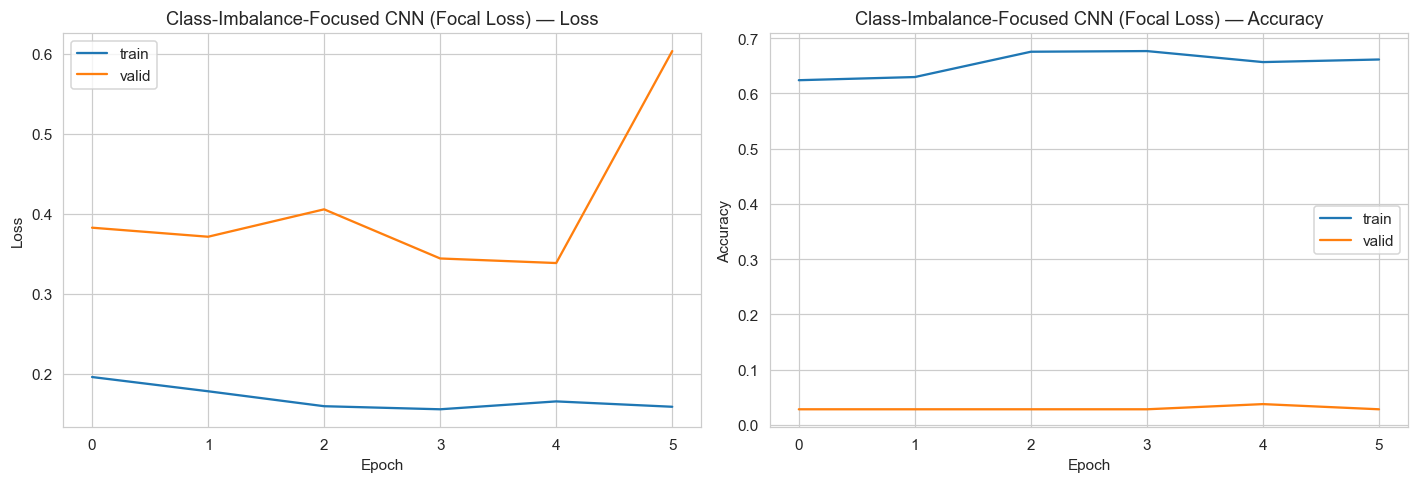

In [35]:
plot_history(history_focal, "Class-Imbalance-Focused CNN (Focal Loss)")


### 11.4 Evaluation on Test Set

In [36]:
test_gen.reset()
y_true_focal = test_gen.classes
pred_probs_focal = focal_model.predict(test_gen, verbose=1)
y_pred_focal = np.argmax(pred_probs_focal, axis=1)

test_accuracy_focal = accuracy_score(y_true_focal, y_pred_focal)
print(f"Focal Loss CNN — Test Accuracy: {test_accuracy_focal:.4f}")


31/31 ━━━━━━━━━━━━━━━━━━━━ 7s 214ms/step
Focal Loss CNN — Test Accuracy: 0.6741


### 11.5 Confusion Matrix

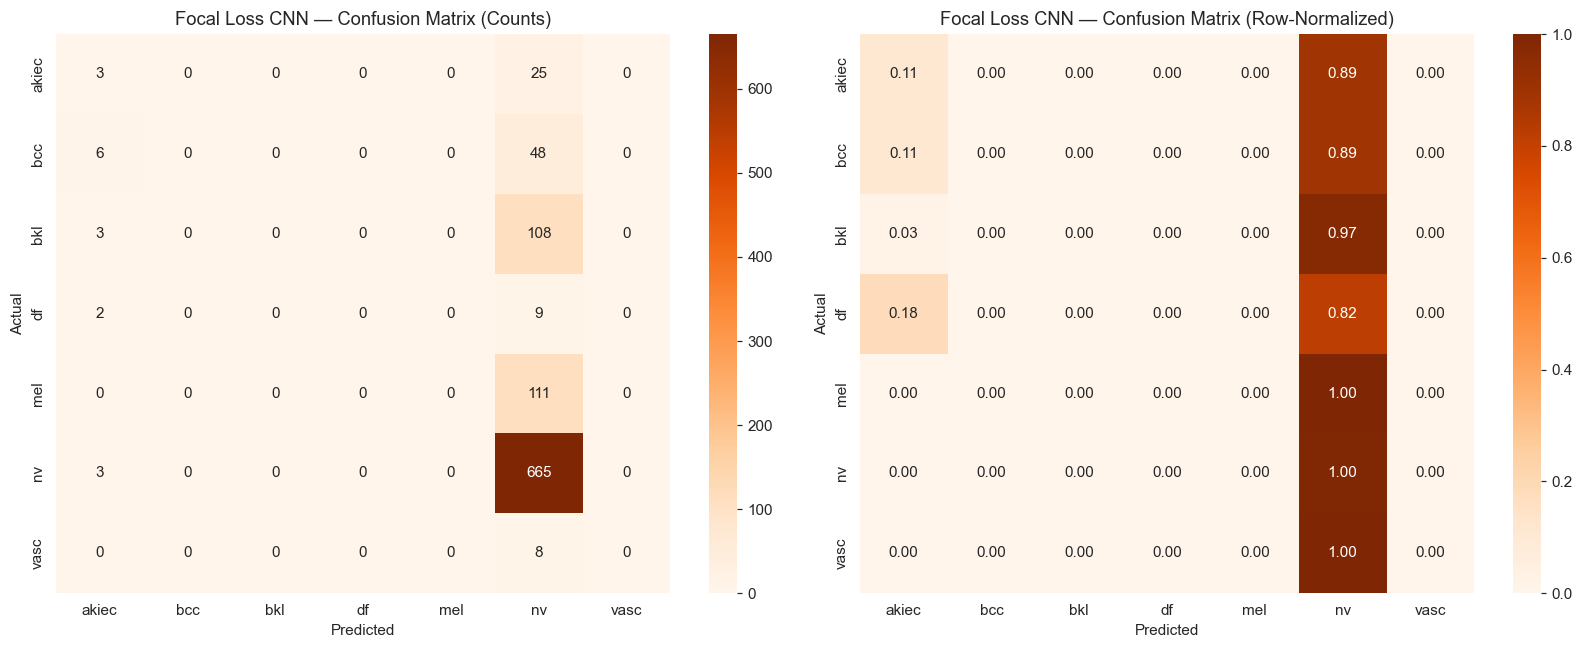

In [37]:
cm_focal = confusion_matrix(y_true_focal, y_pred_focal)
cm_focal_norm = cm_focal.astype(float) / cm_focal.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(cm_focal, annot=True, fmt="d", cmap="Oranges",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_title("Focal Loss CNN — Confusion Matrix (Counts)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

sns.heatmap(cm_focal_norm, annot=True, fmt=".2f", cmap="Oranges",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[1])
axes[1].set_title("Focal Loss CNN — Confusion Matrix (Row-Normalized)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()


### 11.6 Precision, Recall, F1-Score

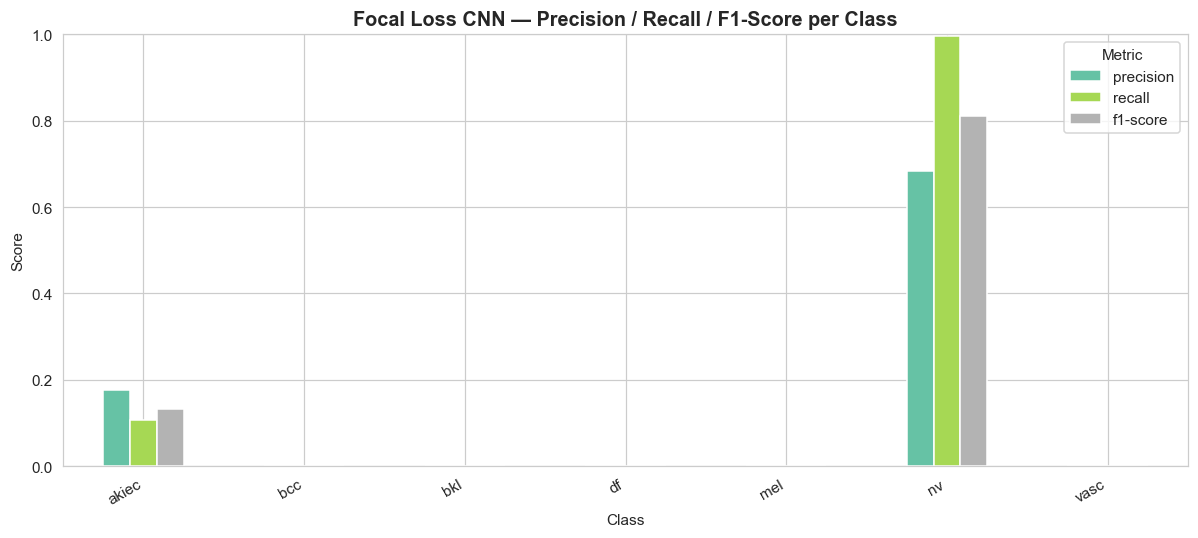

              precision    recall  f1-score   support

       akiec       0.18      0.11      0.13        28
         bcc       0.00      0.00      0.00        54
         bkl       0.00      0.00      0.00       111
          df       0.00      0.00      0.00        11
         mel       0.00      0.00      0.00       111
          nv       0.68      1.00      0.81       668
        vasc       0.00      0.00      0.00         8

    accuracy                           0.67       991
   macro avg       0.12      0.16      0.13       991
weighted avg       0.47      0.67      0.55       991



,precision,recall,f1-score,support
akiec,0.176471,0.107143,0.133333,28.000000
bcc,0.000000,0.000000,0.000000,54.000000
bkl,0.000000,0.000000,0.000000,111.000000
df,0.000000,0.000000,0.000000,11.000000
mel,0.000000,0.000000,0.000000,111.000000
nv,0.682752,0.995509,0.809988,668.000000
vasc,0.000000,0.000000,0.000000,8.000000
accuracy,0.674067,0.674067,0.674067,0.674067
macro avg,0.122746,0.157522,0.134760,991.000000
weighted avg,0.465206,0.674067,0.549753,991.000000


In [38]:
report_dict_focal = classification_report(y_true_focal, y_pred_focal, target_names=CLASS_NAMES,
                                           output_dict=True, zero_division=0)
report_df_focal = pd.DataFrame(report_dict_focal).transpose()

per_class_focal = report_df_focal.loc[CLASS_NAMES, ["precision", "recall", "f1-score"]]
per_class_focal.plot(kind="bar", figsize=(11, 5), colormap="Set2")
plt.title("Focal Loss CNN — Precision / Recall / F1-Score per Class", fontsize=13, fontweight="bold")
plt.ylabel("Score"); plt.xlabel("Class")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

print(classification_report(y_true_focal, y_pred_focal, target_names=CLASS_NAMES, zero_division=0))
report_df_focal


### 11.7 AUC-ROC Curve

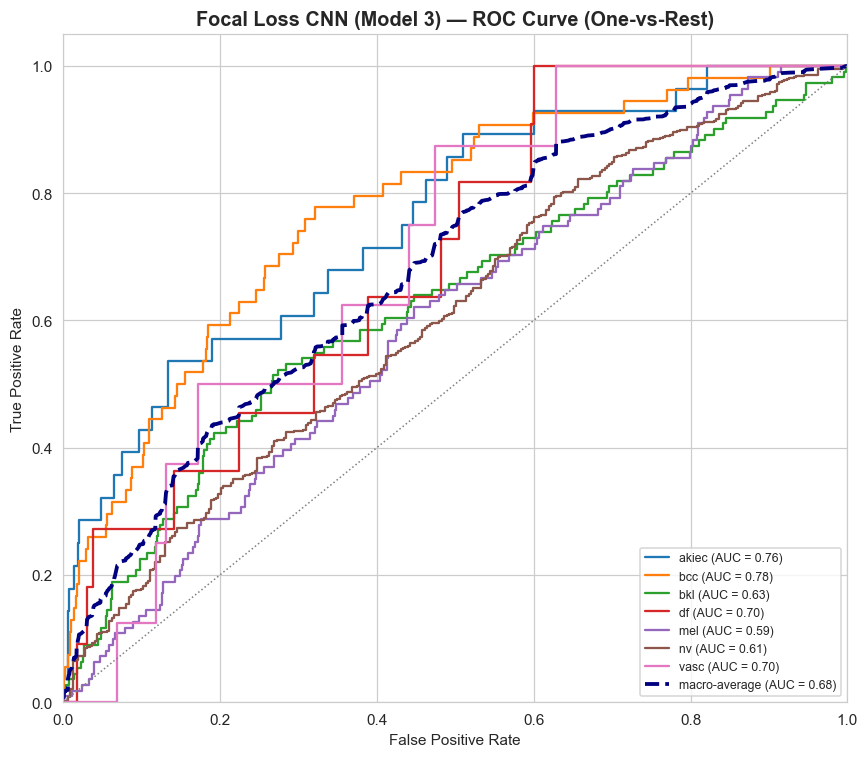

Per-class AUC: {'akiec': 0.757, 'bcc': 0.776, 'bkl': 0.627, 'df': 0.696, 'mel': 0.591, 'nv': 0.608, 'vasc': 0.701}
Macro-average AUC: 0.68


In [39]:
roc_auc_focal = plot_multiclass_roc(y_true_focal, pred_probs_focal, CLASS_NAMES,
                                     title="Focal Loss CNN (Model 3) — ROC Curve (One-vs-Rest)")
print("Per-class AUC:", {CLASS_NAMES[i]: round(roc_auc_focal[i], 3) for i in range(len(CLASS_NAMES))})
print("Macro-average AUC:", round(roc_auc_focal["macro"], 3))


## 12. Model Comparison


In [40]:
comparison_rows = [
    {
        "Model": "Model 1: Baseline CNN",
        "Test Accuracy": test_accuracy,
        "Macro Precision": report_df.loc["macro avg", "precision"],
        "Macro Recall": report_df.loc["macro avg", "recall"],
        "Macro F1-score": report_df.loc["macro avg", "f1-score"],
        "Macro AUC": roc_auc_cnn["macro"],
    },
    {
        "Model": "Model 2: Transfer Learning CNN (MobileNetV2)",
        "Test Accuracy": test_accuracy_tl,
        "Macro Precision": report_df_tl.loc["macro avg", "precision"],
        "Macro Recall": report_df_tl.loc["macro avg", "recall"],
        "Macro F1-score": report_df_tl.loc["macro avg", "f1-score"],
        "Macro AUC": roc_auc_tl["macro"],
    },
    {
        "Model": "Model 3: Class-Imbalance-Focused CNN (Focal Loss)",
        "Test Accuracy": test_accuracy_focal,
        "Macro Precision": report_df_focal.loc["macro avg", "precision"],
        "Macro Recall": report_df_focal.loc["macro avg", "recall"],
        "Macro F1-score": report_df_focal.loc["macro avg", "f1-score"],
        "Macro AUC": roc_auc_focal["macro"],
    },
]

comparison_df = pd.DataFrame(comparison_rows).set_index("Model").round(4)
comparison_df


,Test Accuracy,Macro Precision,Macro Recall,Macro F1-score,Macro AUC
Model,,,,,
Model 1: Baseline CNN,0.6771,0.4064,0.1543,0.1378,0.7742
Model 2: Transfer Learning CNN (MobileNetV2),0.6973,0.4592,0.1944,0.2050,0.8064
Model 3: Class-Imbalance-Focused CNN (Focal Loss),0.6741,0.1227,0.1575,0.1348,0.6803


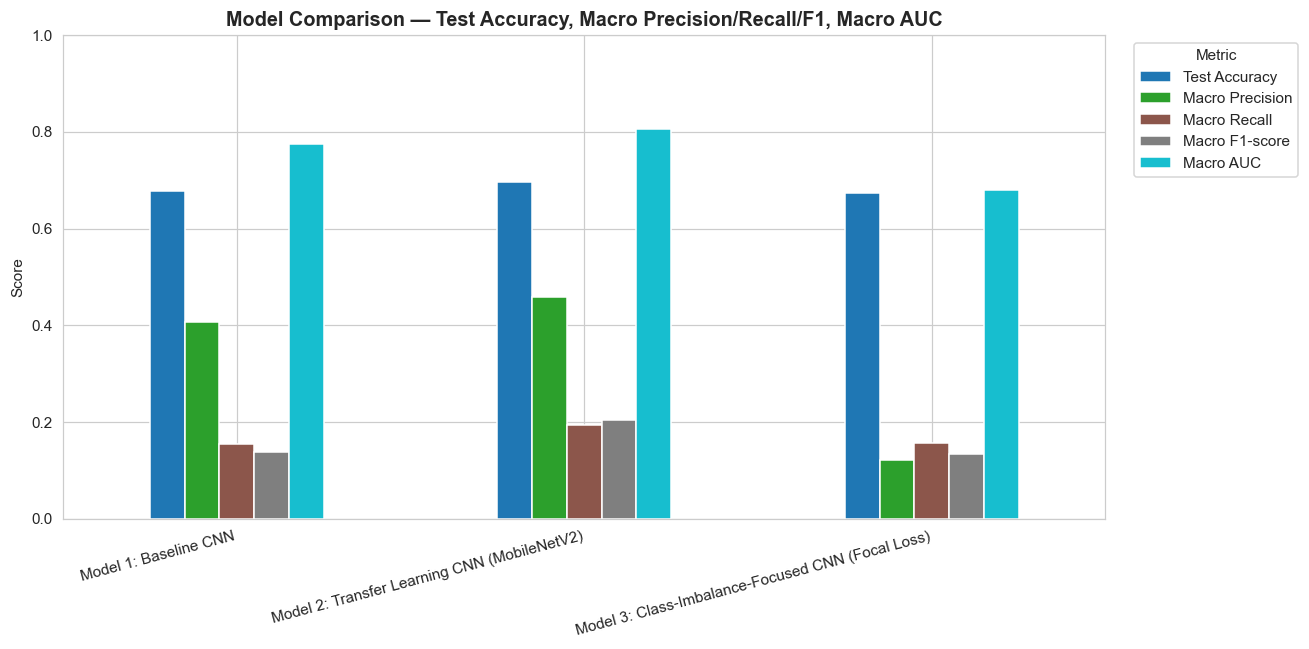

Best-fit model by macro F1-score: Model 2: Transfer Learning CNN (MobileNetV2)


In [41]:
comparison_df[["Test Accuracy", "Macro Precision", "Macro Recall", "Macro F1-score", "Macro AUC"]].plot(
    kind="bar", figsize=(12, 6), colormap="tab10")
plt.title("Model Comparison — Test Accuracy, Macro Precision/Recall/F1, Macro AUC", fontsize=13, fontweight="bold")
plt.ylabel("Score"); plt.xlabel("")
plt.xticks(rotation=15, ha="right")
plt.ylim(0, 1)
plt.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

best_model_name = comparison_df["Macro F1-score"].idxmax()
print(f"Best-fit model by macro F1-score: {best_model_name}")
